# Tunable polarization-dependant honecomb lattice

Hee, we reproduce some of the results from [Lühmann et al. 2014 ](https://journals.aps.org/pra/pdf/10.1103/PhysRevA.90.013614) using the `optilat` and `bloch_schrodinger` packages.

## Lattice construction

The lattice is made of 3 interfering beams coinciding at $120^\circ$ angle. They are all linearily polarized at an angle $\theta$ from the horizontal.

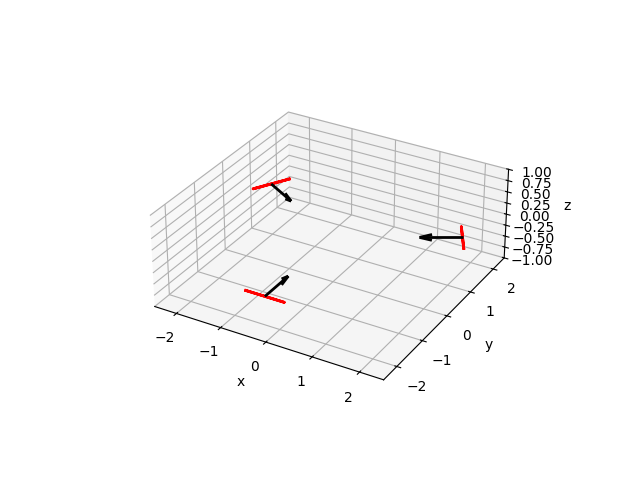

In [1]:
from optilat.builder import OptiLat, Beam
from bloch_schrodinger.potential import Potential, create_parameter
import numpy as np
import matplotlib.pyplot as plt


lamb = 0.83 # Laser wavelength
laser_angles = [np.pi/2 + np.pi * 2 / 3 * i for i in range(3)] # 120deg lasers

theta = create_parameter("theta", np.linspace(0,np.pi/2, 50))

beams = [
    Beam(
        wavelength=lamb, 
        direction=[np.cos(ang), np.sin(ang), 0],
        polar=[np.cos(theta), np.sin(theta)]
    )
    for ang in laser_angles
]

lattice = OptiLat()
lattice.add_beam(beams, [0]*3)

### We can use the plot function to inspect the resulting beam lattice

%matplotlib widget
lattice.plot(box=[5,5,2])
plt.show()


We have defined the optical lattice, it is now time to convert it into a trapping potential. This potential can be splitted into a polarization-independant part, only related to the total light field intensity and a polarization dependant part, induced by the effective magnetic field resulting from the $\sigma_\pm$ polarization-component of the light. Assuming that the total atomic angular momentum F is a good quantum number, We can compute it using the following formula (see [here](https://link.springer.com/article/10.1140/epjd/e2013-30729-x) for a derivation):
$$V(\mathbf{r}) = -\frac{1}{4} |E(\mathbf{r})|^2 \left[ \alpha^s + C \alpha^v \frac{M}{2F} \right]$$
with $C = 2\text{Im}(E^*_x E_y)/|E(\mathbf{r})|^2$, $\alpha^s, \alpha^v$ the scalar and vector polarizabilities, and $M$ is the spin projection along th quantization axis (here the z-axis for simplicity). The polarizabilities can be computed using the relevant tabulated data for the atomic species considered, but in this tutorial, we are going to choose them as arbitrary (but typical) values.

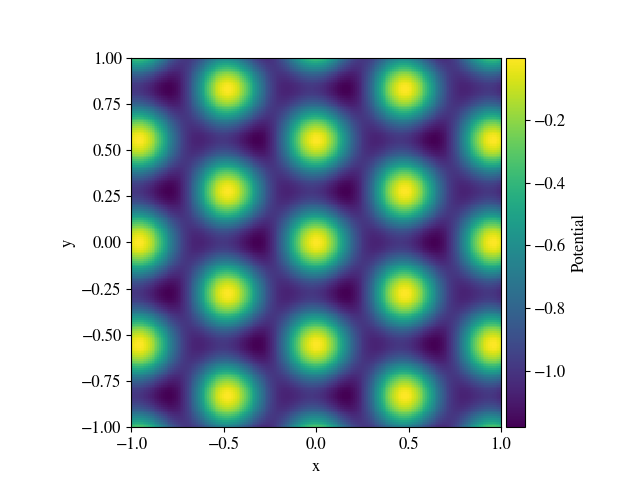

In [7]:
# We create first an empty potential object, over which we are going to compute the effect of the AC Stark effect
honeycomb = Potential(
    [[2,0], [0,2]],
    resolution=(200,200)
)

Field = lattice.compute_fields(x = honeycomb.x, y = honeycomb.y).squeeze() # We squeeze Fields to remove the size-1 Field dimension
# We are going to define every constant in arbitrary units here
E1 = 1 # The amplitude of a single beam, in arbitrary units
alpha_s = 1 # Scalar polarizability
alpha_v = 0.1 # Vector polarizability

F = 3 # Atomic total angular momentum
M = F # Projection on the quantization axis



C = 2*(Field.conj().sel(component=0) * Field.sel(component = 1)).imag / (abs(Field)**2).sum("component")
V = -1/4 * E1**2 * (abs(Field)**2).sum("component") * (alpha_s + C * alpha_v*M/2/F)

honeycomb.set(V)

honeycomb.plot()
plt.show()

Looking at the potential, we can clearly identify two limit behaviors:
+ When $\theta$ is close to 0, corresponding to an in-plane polarization, the beams form a honeycomb lattice with a staggered on-site energy.
+ When $\theta$ is close to $\pi/2$, the beams form a triangular lattice.

We can interprate those results by looking at the contributions from the polarization-independant and dependant parts. We are going to use the `plot_eigenvector` function from the `bloc_schrodinger` module to do so. 

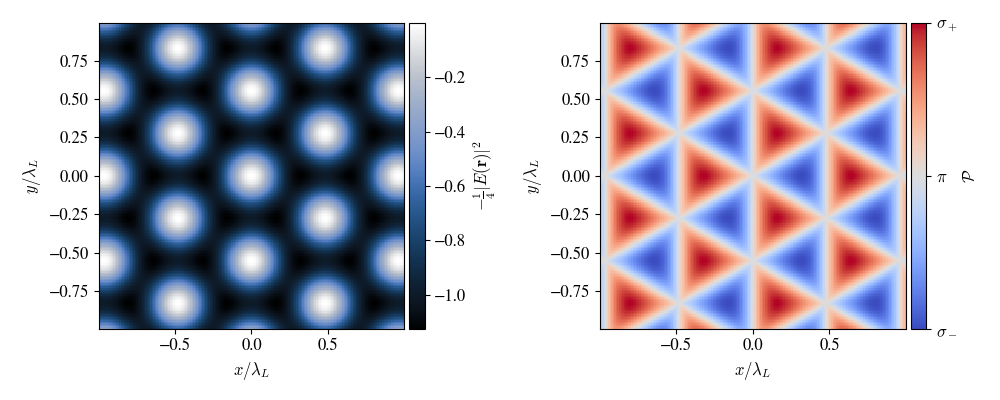

In [ ]:
from bloch_schrodinger.plotting import plot_eigenvector
from cmcrameri.cm import oslo as cmp

pot_template = {
    "fkwargs":{
        "cmap": cmp,
    },
    "autoscale": True,
    "colorbar":{
        "kwargs":{"label":r"$-\frac{1}{4} |E(\mathbf{r})|^2$"},
    }
}

pol_template = {
    "fkwargs":{
        "cmap": "coolwarm"
    },
    "colorbar":{
        "kwargs":{"label":r"$\mathcal{P}$"},
        "ticks":[-1,0,1],
        "tickslabel":[r"$\sigma_-$", r"$\pi$", r"$\sigma_+$"]
    }
}


E = -1/4 * E1**2 * (abs(Field)**2).sum("component") # Polarization independant potential

fig, axes = plot_eigenvector([[E, C]], [[None, None]], [[pot_template, pol_template]])
fig.set_size_inches(10,4)
axes[0,0].set_xlabel(r"$x/\lambda_L$")
axes[0,1].set_xlabel(r"$x/\lambda_L$")
axes[0,0].set_ylabel(r"$y/\lambda_L$")
axes[0,1].set_ylabel(r"$y/\lambda_L$")

plt.show()

We can clearly see what is happening here. The scalar part of the potential is only modified by a global proportional factor that goes to 0 and changes sign for $\theta \approx 35^\circ$, while the polarization dependant potential is responsible for the on-site energy staggering of the honeycomb lattice sites. A much more detailled analysis of the lattice can be found in [[Soltan-Panahi2010]](https://arxiv.org/pdf/1005.1276) and [[Lühmann2014]](https://journals.aps.org/pra/pdf/10.1103/PhysRevA.90.013614).

## Relative phase control

Additional degrees of freedom can be leveraged by controling the relative phase between in-plane and out-of-plane polarization component independantly for each of the beams. Each beam's polarization can be described as:
$$\mathbf{e}_j = \text{cos}(\theta_j)\mathbf{e}_{p,j} + \text{sin}(\theta_j) e^{i\phi_j} \mathbf{e}_{s,j}$$

By controlling selectively the relative phases $\phi_j$, we can control the out-of-plane potential (a triangular lattice, as we have seen) position independantly from the in-plane potential (a honeycomb lattice). Let's fix $\phi_1$ to 0 and see how the other phases affect the potential.

In [54]:
lamb = 0.83 # Laser wavelength
laser_angles = [np.pi/2 + np.pi * 2 / 3 * i for i in range(3)] # 120deg lasers

theta = create_parameter("theta", np.linspace(0,np.pi/2, 11))
phi2 = create_parameter("phi2", np.linspace(0,np.pi*2, 6, endpoint=False))
phi3 = create_parameter("phi3", np.linspace(0,np.pi*2, 6, endpoint=False))

beams = []
for i, ang in enumerate(laser_angles):
    
    if i == 0:
        phase = 1
    elif i == 1:
        phase = np.exp(1j*phi2)
    else:
        phase = np.exp(1j*phi3)
        
    beam = Beam(
        amplitude=1,
        wavelength=lamb, 
        direction=[np.cos(ang), np.sin(ang), 0],
        polar=[np.cos(theta), np.sin(theta)*phase]
    )
    
    beams += [beam]


lattice = OptiLat()
lattice.add_beam(beams, [0]*3)

# We create first an empty potential object, over which we are going to compute the effect of the AC Stark effect
honeycomb = Potential(
    [[2,0], [0,2]],
    resolution=(200,200)
)

Field = lattice.compute_fields(x = honeycomb.x, y = honeycomb.y).squeeze() # We squeeze Fields to remove the size-1 Field dimension
# We are going to define every constant in arbitrary units here
E1 = 1 # The amplitude of a single beam, in arbitrary units
alpha_s = 1 # Scalar polarizability
alpha_v = 0.1 # Vector polarizability

F = 3 # Atomic total angular momentum
M = F # Projection on the quantization axis



C = 2*(Field.conj().sel(component=0) * Field.sel(component = 1)).imag / (abs(Field)**2).sum("component")
V = -1/4 * E1**2 * (abs(Field)**2).sum("component") * (alpha_s + C * alpha_v*M/2/F)

honeycomb.set(V)


To see the effects of $\phi_j$, we can fix $\theta = 0$ and look at the potential:

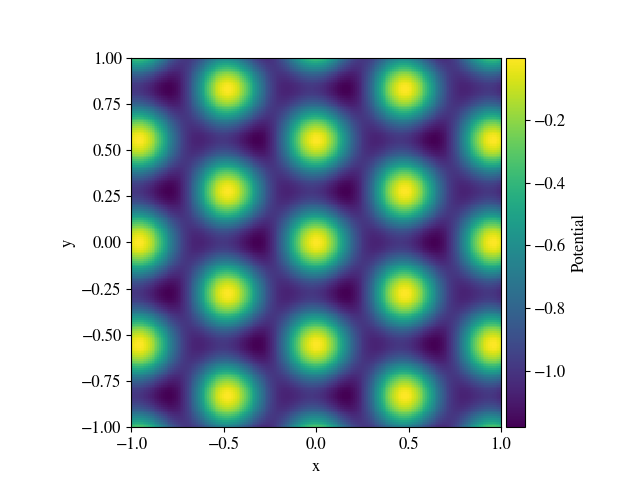

In [55]:

honeycomb.plot()
plt.show()

In particular, for $\phi_2 = 2\pi/3, \phi_3 = 4\pi/3$, the out-of-plane lattice is centered on one of the in-plane potential's minima, leading to the creation of a polarization-independant sublattice offset. Coupled to the vector polarizability contribution, one can design lattices with a wide range of  polarization and energy pattern combinations. Feel free to play aroundthe various parameters to explore the possibilities.